In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from torch import nn
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
from model_torch import CNNModel, train_loop, test_loop, train_model
from torchvision.transforms import v2
import matplotlib.pyplot as plt

In [3]:
# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

datasets.FashionMNIST.mirrors = [
    "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/", # Fallback fallback
    "https://githubusercontent.com"
]

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

# 4. Partition the 60k training set into 50k Train / 10k Validation
# You can adjust the 50000/10000 split ratio depending on your preferences
train_size = 50000
val_size = 10000

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

training_data, val_data = random_split(
    dataset=training_data,
    lengths=[train_size, val_size],
    generator=torch.Generator().manual_seed(42) # Ensures reproducibility
)

In [4]:
train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)
test_loader = DataLoader(test_data  , batch_size=256, shuffle=False)

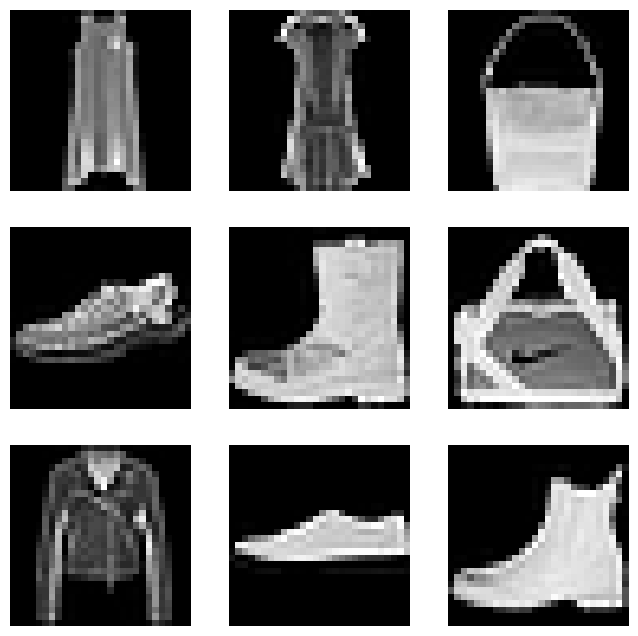

In [5]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    # plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [6]:
num_classes = len(training_data.dataset.classes)
print(f"Num Classes {num_classes}")
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
print(device)

Num Classes 10
Using mps device
mps


In [ ]:
learning_rate = 1e-3
weight_decay = 1e-4
batch_size = 64


model = CNNModel(num_classes).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)
loss_fn = nn.CrossEntropyLoss()

In [11]:
epochs = 10

history = train_model(epochs,model, train_loader, val_loader, loss_fn, optimizer, batch_size, device, num_classes)
print(history)

loss: 0.605488  [   64/50000]
loss: 0.646159  [ 6464/50000]
loss: 0.621934  [12864/50000]
loss: 0.732200  [19264/50000]
loss: 0.452612  [25664/50000]
loss: 0.595616  [32064/50000]
loss: 0.438895  [38464/50000]
loss: 0.439600  [44864/50000]
Test Loss: 0.5619, Test Accuracy: 0.7941
Done!
loss: 0.600768  [   64/50000]
loss: 0.327783  [ 6464/50000]
loss: 0.429150  [12864/50000]
loss: 0.518392  [19264/50000]
loss: 0.618150  [25664/50000]
loss: 0.514984  [32064/50000]
loss: 0.472528  [38464/50000]
loss: 0.455919  [44864/50000]
Test Loss: 0.4935, Test Accuracy: 0.8215
Done!
loss: 0.370830  [   64/50000]
loss: 0.506044  [ 6464/50000]
loss: 0.321492  [12864/50000]
loss: 0.569466  [19264/50000]
loss: 0.546501  [25664/50000]
loss: 0.379001  [32064/50000]
loss: 0.324614  [38464/50000]
loss: 0.354118  [44864/50000]
Test Loss: 0.4566, Test Accuracy: 0.8331
Done!
loss: 0.598135  [   64/50000]
loss: 0.333028  [ 6464/50000]
loss: 0.422034  [12864/50000]
loss: 0.303078  [19264/50000]
loss: 0.376855  [25

In [ ]:
model.train()

running_loss = 0.0
correct = 0
total = 0
epochs = 10

history = {
    "train_acc": [],
    "train_loss": [],
    "val_acc": [],
    "val_loss": [],
}

for t in range(epochs):
    train_correct,train_loss = train_loop(train_loader, model, loss_fn, optimizer, batch_size, device)
    test_correct,test_loss, (y_pred, y) = test_loop(train_loader, model, loss_fn, device) # for evaluate in each epoch
    history["train_acc"].append(train_correct)
    history["train_loss"].append(train_loss)
    history["val_acc"].append(test_correct)
    history["val_loss"].append(test_loss)
    
    print("Done!")

loss: 0.396104  [   64/50000]
loss: 0.298290  [ 6464/50000]
loss: 0.212865  [12864/50000]
loss: 0.364090  [19264/50000]
loss: 0.393014  [25664/50000]
loss: 0.391780  [32064/50000]
loss: 0.373050  [38464/50000]
loss: 0.404165  [44864/50000]
Test Loss: 0.3324, Test Accuracy: 0.8834
Done!
loss: 0.359364  [   64/50000]
loss: 0.371957  [ 6464/50000]
loss: 0.195993  [12864/50000]
loss: 0.246571  [19264/50000]
loss: 0.301508  [25664/50000]
loss: 0.163293  [32064/50000]
loss: 0.216663  [38464/50000]
loss: 0.218625  [44864/50000]
Test Loss: 0.2940, Test Accuracy: 0.8932
Done!
loss: 0.232816  [   64/50000]
loss: 0.288912  [ 6464/50000]
loss: 0.369900  [12864/50000]
loss: 0.311459  [19264/50000]
loss: 0.204347  [25664/50000]
loss: 0.346379  [32064/50000]
loss: 0.376049  [38464/50000]
loss: 0.222365  [44864/50000]
Test Loss: 0.3074, Test Accuracy: 0.8918
Done!
loss: 0.255910  [   64/50000]
loss: 0.176747  [ 6464/50000]
loss: 0.370601  [12864/50000]
loss: 0.371552  [19264/50000]
loss: 0.347695  [25

In [16]:
print("Precision:", history["val_precision"])
print("Recall:", history["val_recall"])
print("F1:", history["val_f1"])

Precision: tensor(0.8378, device='mps:0')
Recall: tensor(0.8385, device='mps:0')
F1: tensor(0.8376, device='mps:0')


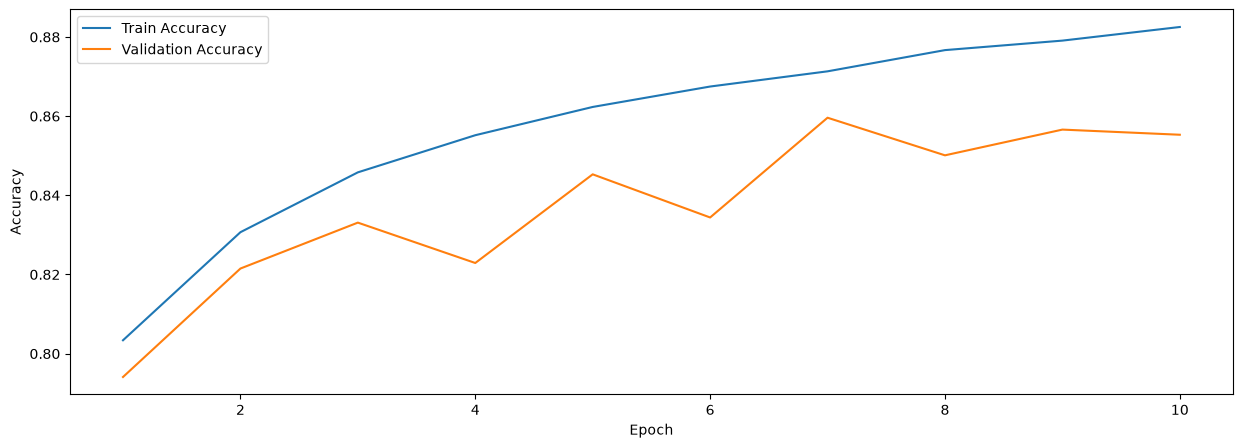

In [12]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(15,5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

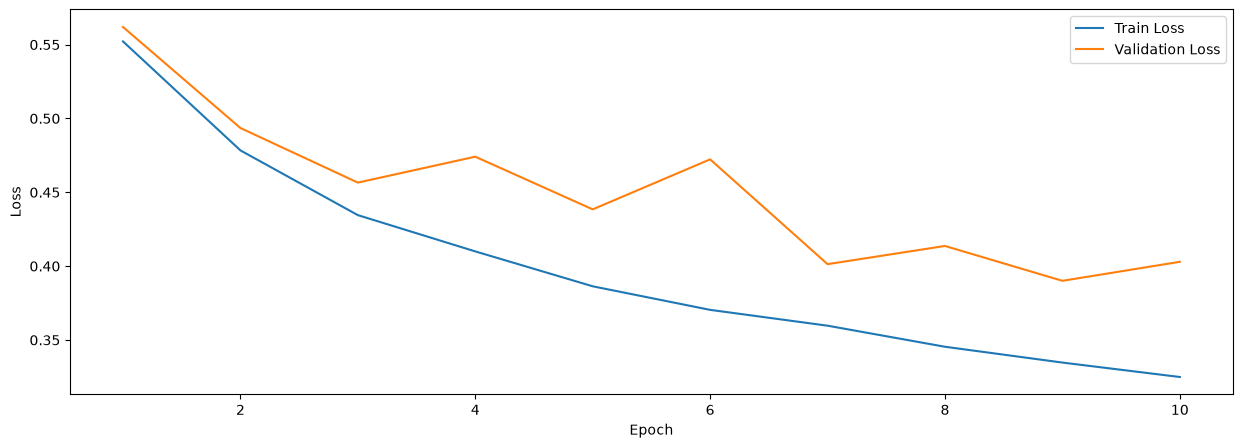

In [13]:
plt.figure(figsize=(15,5))

plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()